In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use("fivethirtyeight")
%matplotlib inline

In [ ]:
df=pd.read_csv('/content/IRIS (1).csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.shape

(150, 5)

In [ ]:
# df.drop('Id',axis=1,inplace=True)

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df['species'].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<Axes: >

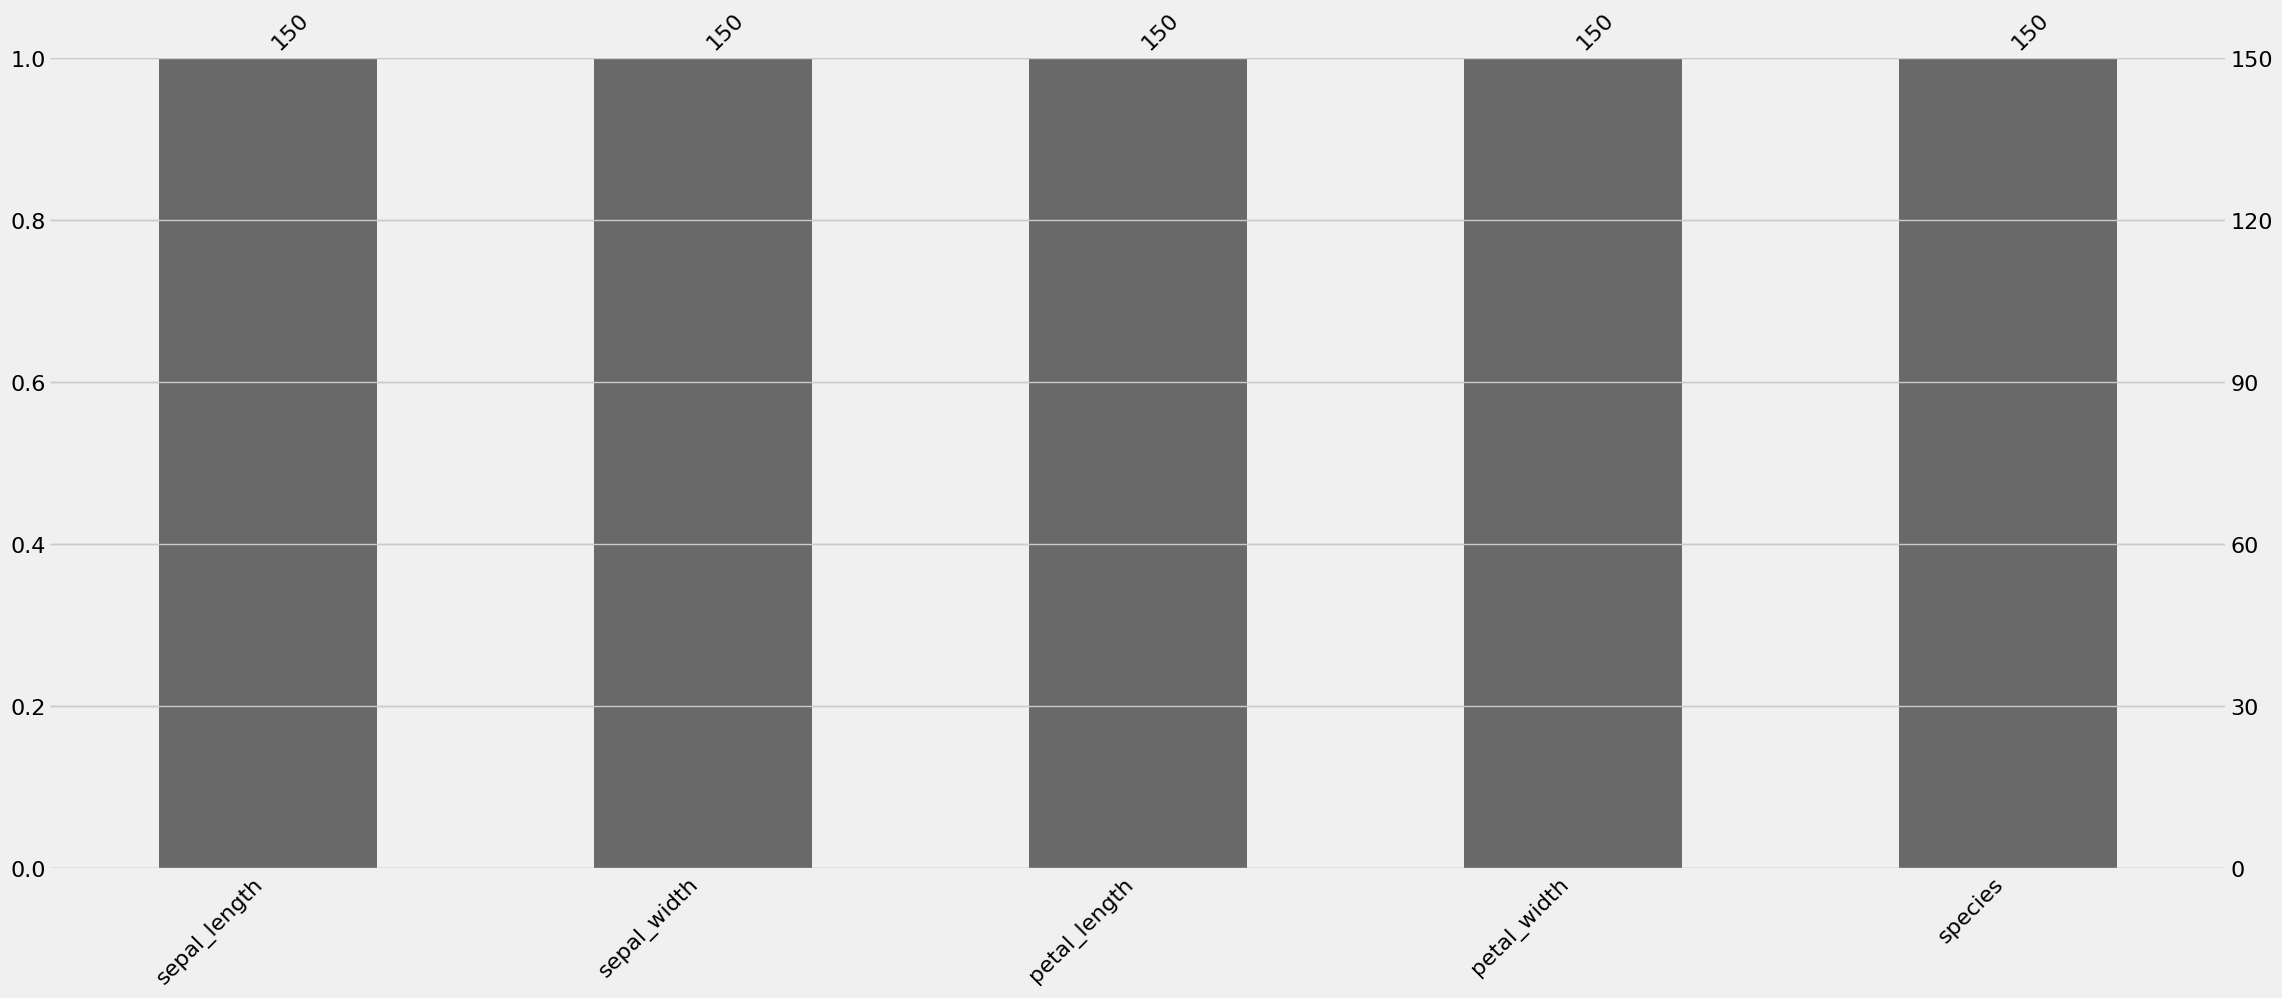

In [ ]:
import missingno as msno
msno.bar(df)

In [ ]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='species', ylabel='sepal_length'>

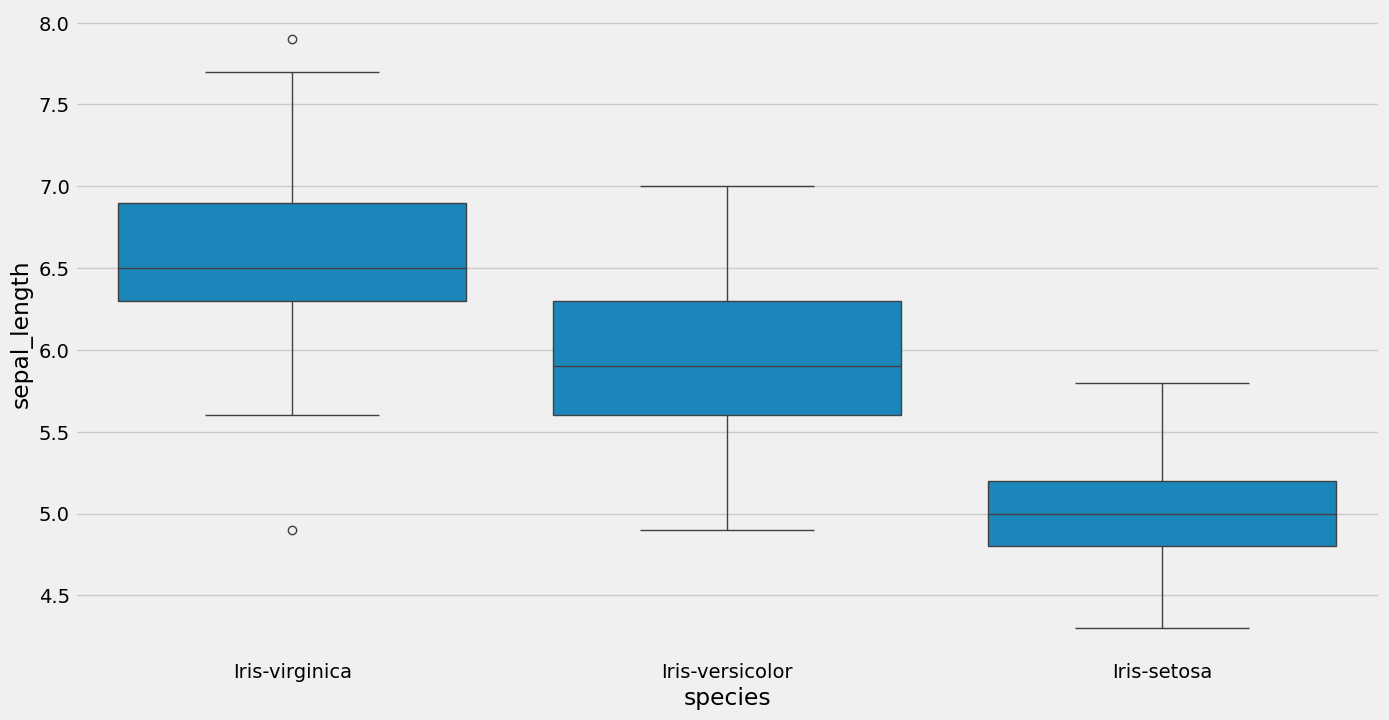

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(x='species',y='sepal_length',data=df.sort_values('sepal_length',ascending=False))

<Axes: xlabel='sepal_width', ylabel='sepal_length'>

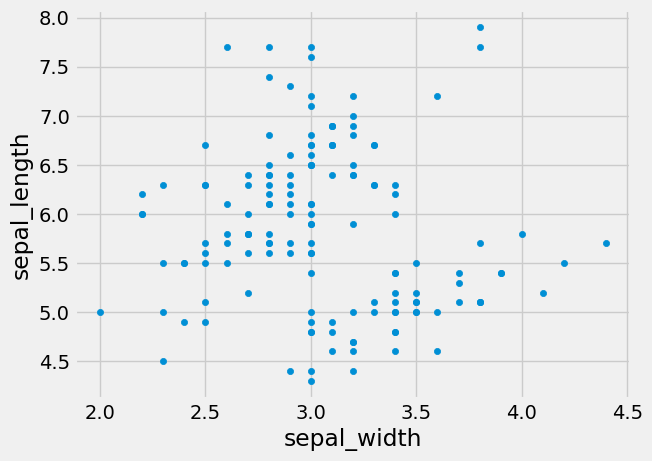

In [ ]:
df.plot(kind='scatter',x='sepal_width',y='sepal_length')

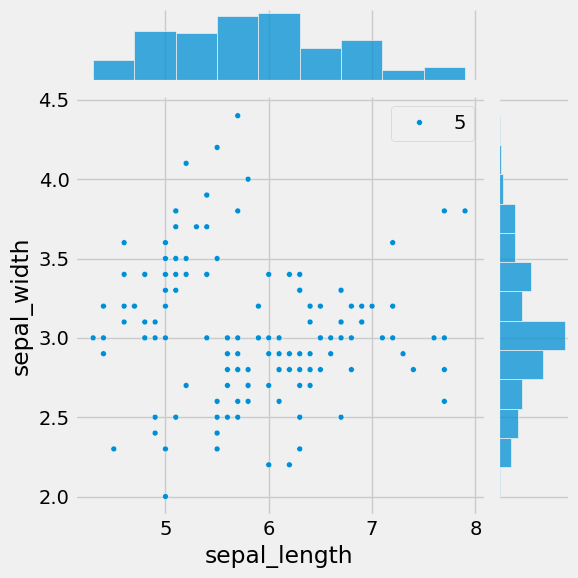

In [ ]:
sns.jointplot(x="sepal_length", y="sepal_width", data=df, size=5)

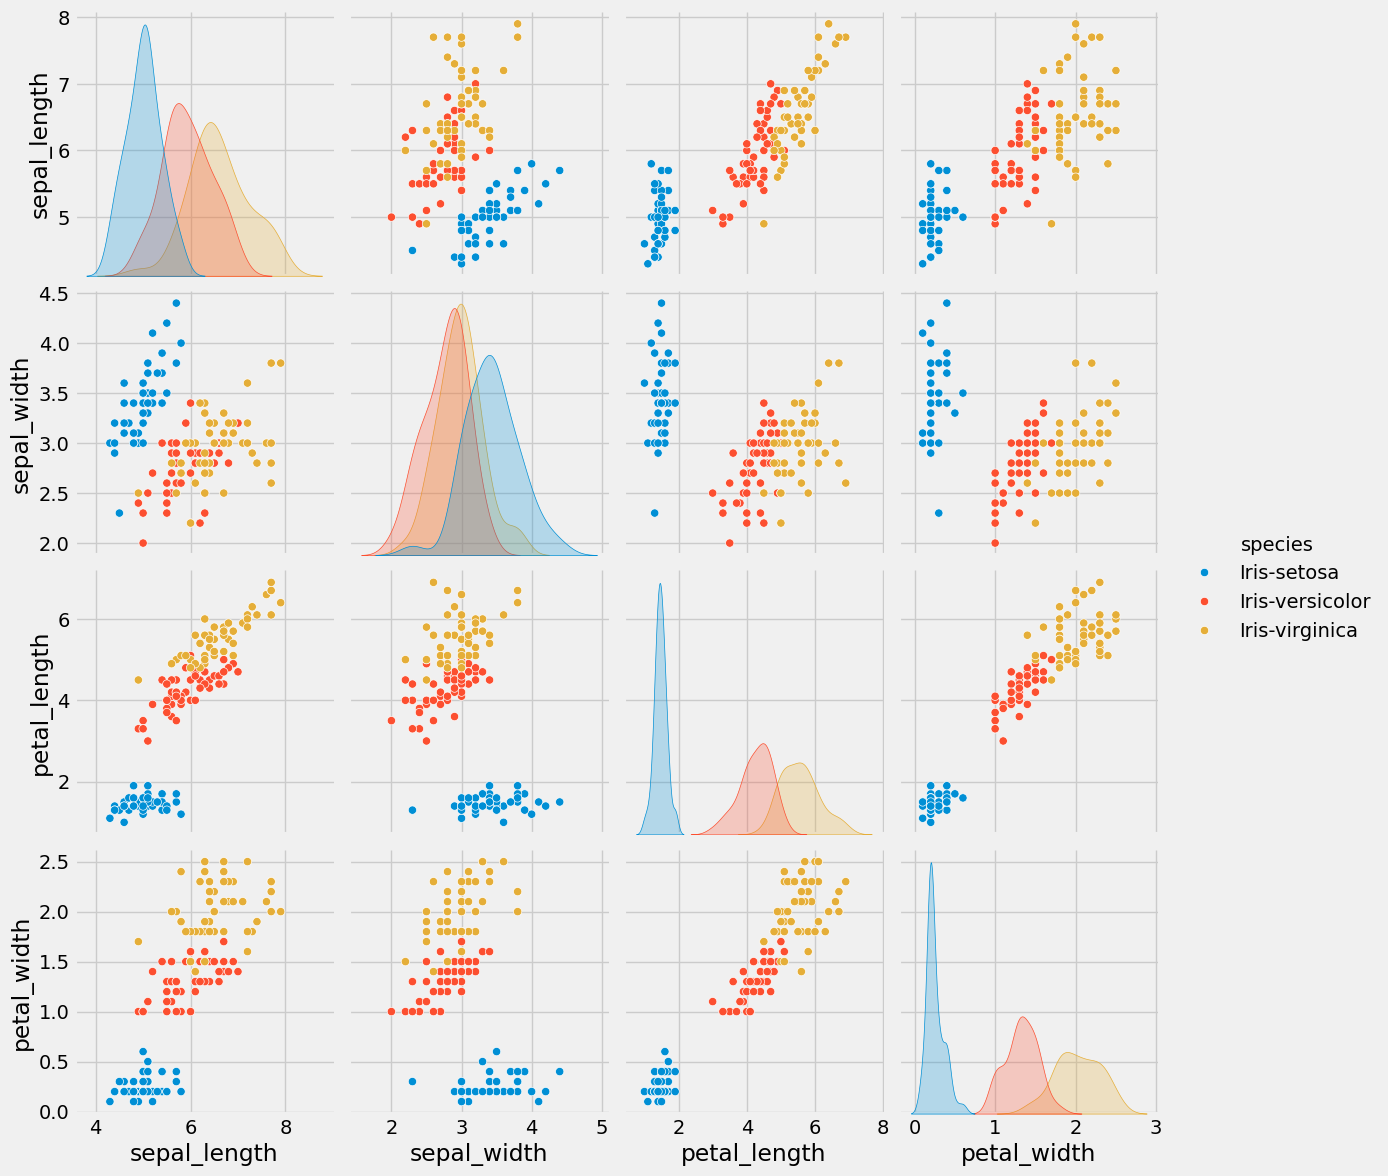

In [ ]:
sns.pairplot(df, hue="species", size=3)

array([[<Axes: title={'center': 'petal_length'}, xlabel='[species]'>,
        <Axes: title={'center': 'petal_width'}, xlabel='[species]'>],
       [<Axes: title={'center': 'sepal_length'}, xlabel='[species]'>,
        <Axes: title={'center': 'sepal_width'}, xlabel='[species]'>]],
      dtype=object)

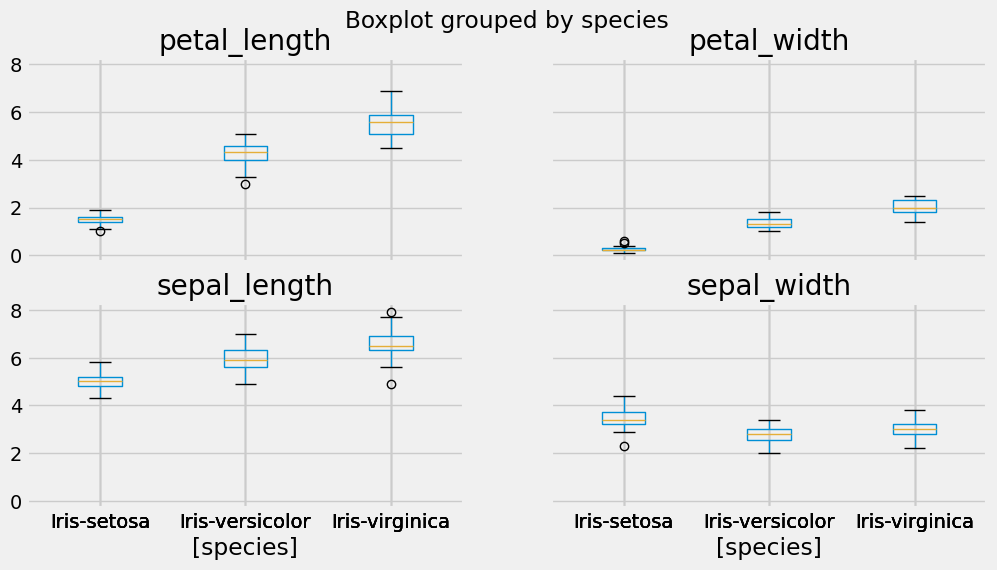

In [ ]:
df.boxplot(by="species", figsize=(12, 6))

<Axes: >

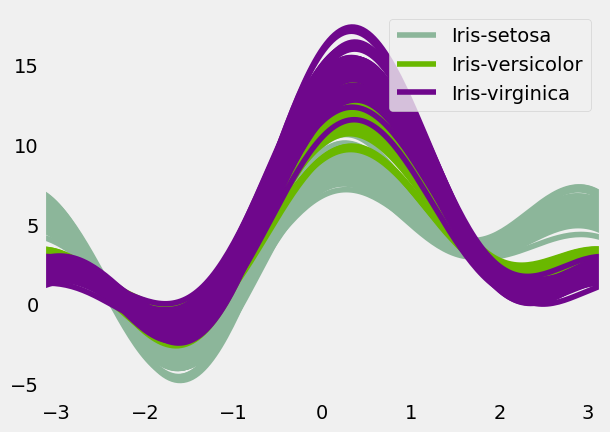

In [ ]:
import pandas.plotting
from pandas.plotting import andrews_curves
andrews_curves(df, "species")

<Figure size 1500x1500 with 0 Axes>

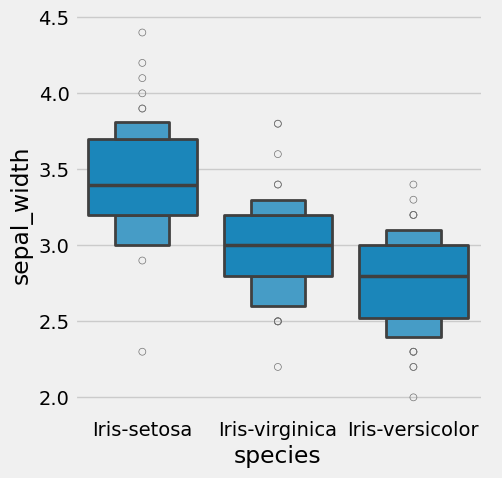

In [ ]:
plt.figure(figsize=(15,15))
sns.catplot(x='species',y='sepal_width',data=df.sort_values('sepal_width',ascending=False),kind='boxen')

<Axes: xlabel='species', ylabel='sepal_width'>

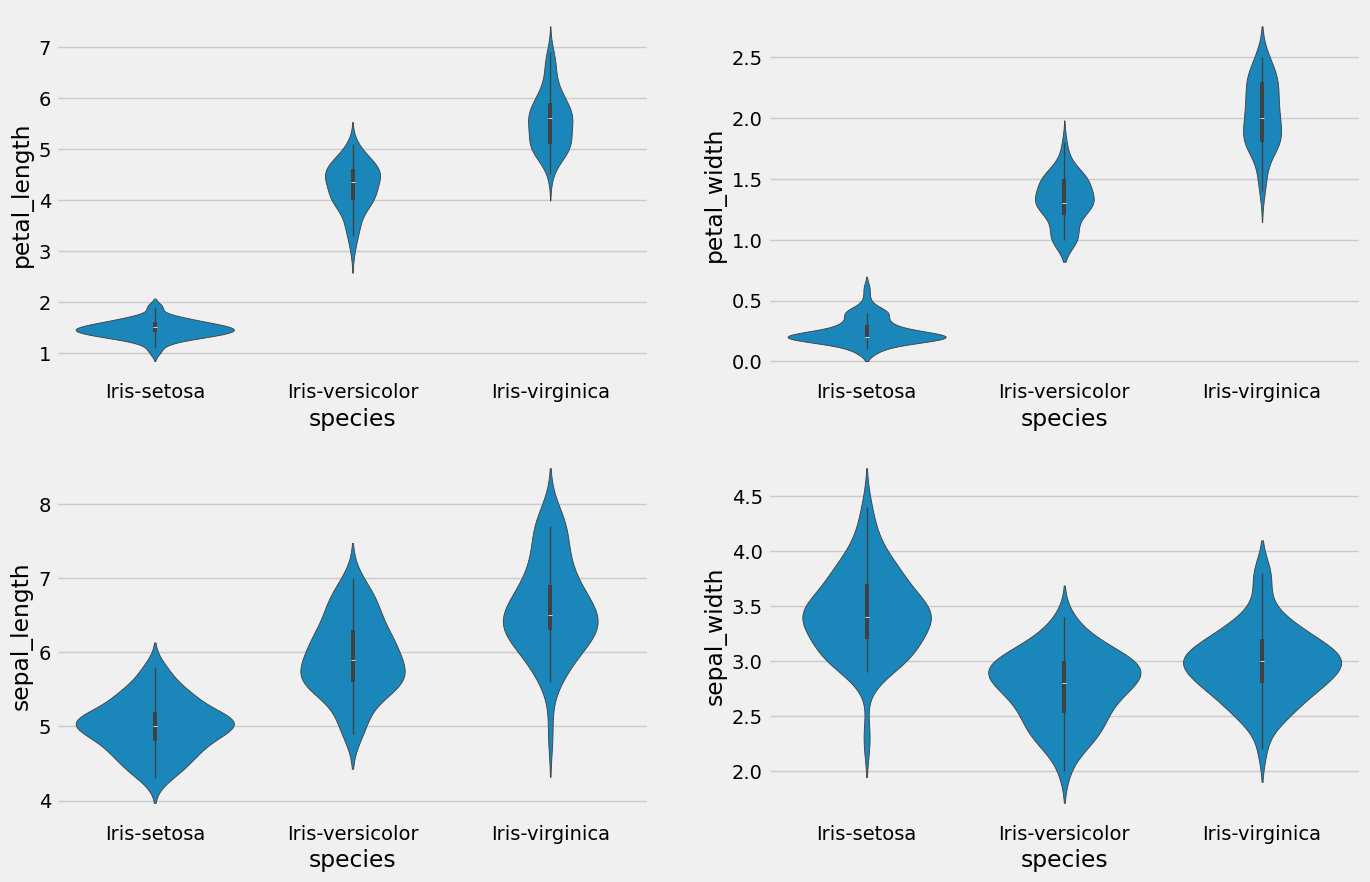

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.violinplot(x='species',y='petal_length',data=df)
plt.subplot(2,2,2)
sns.violinplot(x='species',y='petal_width',data=df)
plt.subplot(2,2,3)
sns.violinplot(x='species',y='sepal_length',data=df)
plt.subplot(2,2,4)
sns.violinplot(x='species',y='sepal_width',data=df)

In [ ]:
X=df.drop('species',axis=1)
y=df['species']

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

In [ ]:
df['species'] = pd.Categorical(df.species)
df['species'] = df.species.cat.codes

y = to_categorical(df.species)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,stratify=y,random_state=123)

In [ ]:
model=Sequential()
model.add(Dense(100,activation='relu',input_shape=(4,)))

model.add(Dense(3,activation='softmax'))

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,epochs=45,validation_data=(X_test, y_test))


Epoch 1/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.3235 - loss: 1.8479 - val_accuracy: 0.3333 - val_loss: 1.5166
Epoch 2/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3235 - loss: 1.4213 - val_accuracy: 0.3333 - val_loss: 1.1878
Epoch 3/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3235 - loss: 1.1319 - val_accuracy: 0.3333 - val_loss: 0.9832
Epoch 4/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5196 - loss: 0.9668 - val_accuracy: 0.8889 - val_loss: 0.8839
Epoch 5/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7549 - loss: 0.8818 - val_accuracy: 0.6667 - val_loss: 0.8495
Epoch 6/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6471 - loss: 0.8606 - val_accuracy: 0.6667 - val_loss: 0.8331
Epoch 7/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6471 - loss: 0.8393 - val_accuracy: 0.6667 - val_loss: 0.8066
Epoch 8/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6569 - loss: 0.8107 - val_accuracy: 0.6667 - val_loss: 0.7742

In [ ]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8889 - loss: 0.3828


[0.3827706277370453, 0.8888888955116272]

In [ ]:
pred = model.predict(X_test[:10])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[0.00930487 0.2802775  0.71041757]
 [0.00613546 0.23498608 0.75887847]
 [0.07421856 0.57206523 0.35371614]
 [0.04548334 0.48777077 0.4667459 ]
 [0.9088299  0.0754227  0.01574744]
 [0.04546926 0.5534983  0.4010324 ]
 [0.00832407 0.21225896 0.7794169 ]
 [0.00909791 0.22741547 0.7634865 ]
 [0.9076082  0.07709118 0.01530056]
 [0.01935574 0.3650637  0.6155805 ]]


In [ ]:
p=np.argmax(pred,axis=1)
print(p)
print(y_test[:10])

[2 2 1 1 0 1 2 2 0 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [ ]:
history.history['accuracy']

[0.3235294222831726,
 0.3235294222831726,
 0.3235294222831726,
 0.5196078419685364,
 0.7549019455909729,
 0.6470588445663452,
 0.6470588445663452,
 0.656862735748291,
 0.656862735748291,
 0.8823529481887817,
 0.8921568393707275,
 0.9215686321258545,
 0.8725489974021912,
 0.8725489974021912,
 0.9215686321258545,
 0.9313725233078003,
 0.9313725233078003,
 0.8823529481887817,
 0.8823529481887817,
 0.9313725233078003,
 0.9607843160629272,
 0.9313725233078003,
 0.9313725233078003,
 0.9313725233078003,
 0.9607843160629272,
 0.9215686321258545,
 0.9215686321258545,
 0.9215686321258545,
 0.9313725233078003,
 0.9215686321258545,
 0.813725471496582,
 0.813725471496582,
 0.8823529481887817,
 0.9215686321258545,
 0.9313725233078003,
 0.9215686321258545,
 0.9313725233078003,
 0.9313725233078003,
 0.9313725233078003,
 0.9411764740943909,
 0.9607843160629272,
 0.9607843160629272,
 0.970588207244873,
 0.970588207244873,
 0.9607843160629272]

In [ ]:
history.history['val_accuracy']

[0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.8888888955116272,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.8444444537162781,
 0.9777777791023254,
 0.9777777791023254,
 0.8888888955116272,
 0.8444444537162781,
 0.8666666746139526,
 0.9333333373069763,
 0.9555555582046509,
 0.8666666746139526,
 0.8444444537162781,
 0.9111111164093018,
 0.9777777791023254,
 0.9555555582046509,
 0.8888888955116272,
 0.9555555582046509,
 0.9555555582046509,
 0.9555555582046509,
 0.8666666746139526,
 0.8666666746139526,
 0.9333333373069763,
 0.8888888955116272,
 0.8222222328186035,
 0.7777777910232544,
 0.8222222328186035,
 0.8888888955116272,
 0.9333333373069763,
 0.8888888955116272,
 0.8888888955116272,
 0.9555555582046509,
 0.9333333373069763,
 0.9555555582046509,
 0.9555555582046509,
 0.9777777791023254,
 0.9777777791023254,
 0.9777777791023254,
 0.9555555582046509,
 0.8888888955116272]

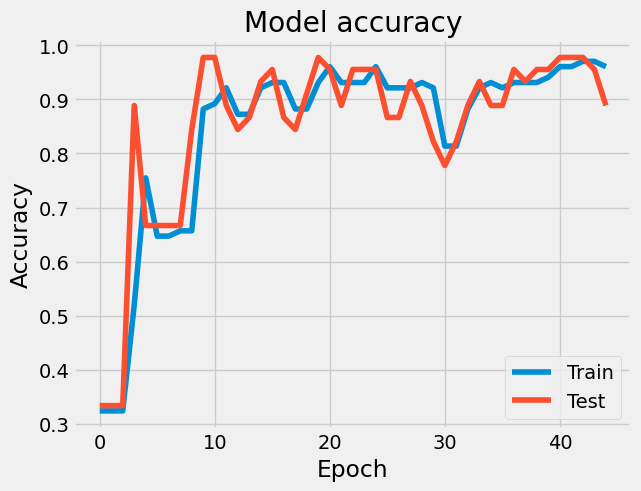

In [ ]:
plt.figure()


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

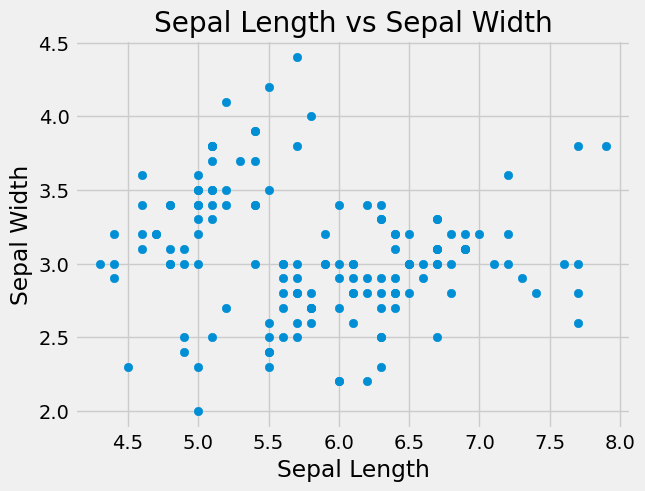

In [ ]:
# plot a scatter graph between sepal_length and sepal_width.

import matplotlib.pyplot as plt

plt.scatter(df['sepal_length'], df['sepal_width'])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Sepal Width")
plt.show()

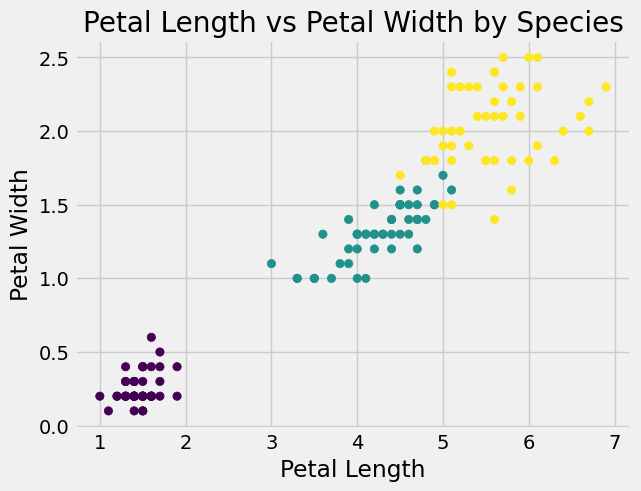

In [ ]:
# Plot petal_length vs petal_width and color points by species.

import matplotlib.pyplot as plt

plt.scatter(df['petal_length'], df['petal_width'], c=df['species'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width by Species")
plt.show()

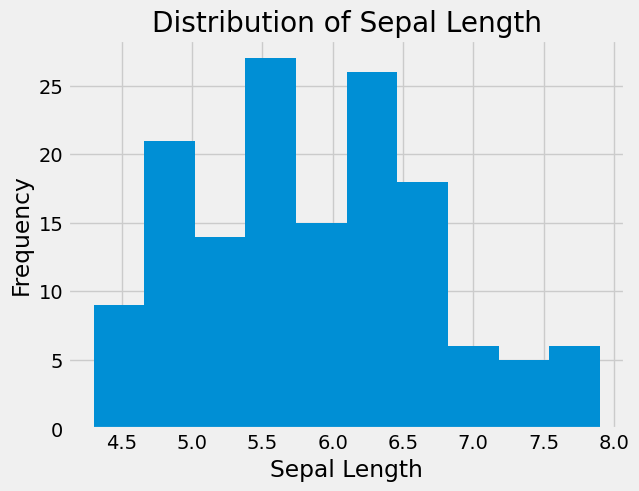

In [ ]:
# Draw a histogram of sepal_length.

plt.hist(df['sepal_length'], bins=10)
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sepal Length")
plt.show()

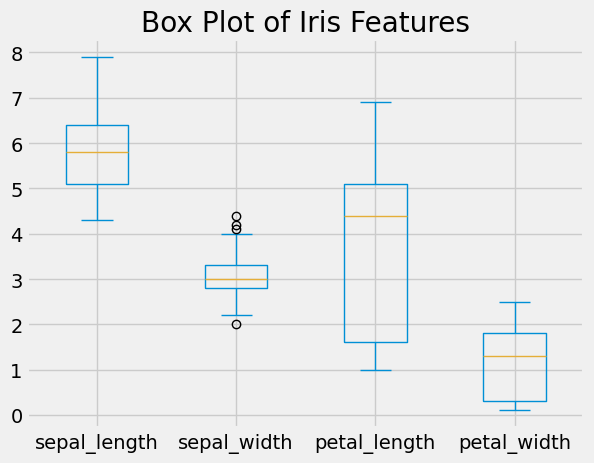

In [ ]:
# Create a boxplot for all numerical columns.

df[['sepal_length','sepal_width','petal_length','petal_width']].plot.box()
plt.title("Box Plot of Iris Features")
plt.show()

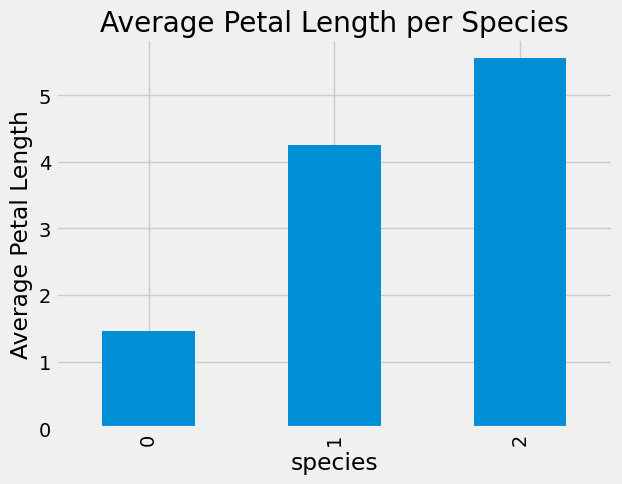

In [ ]:
# Plot average petal_length for each species.

df.groupby('species')['petal_length'].mean().plot(kind='bar')
plt.ylabel("Average Petal Length")
plt.title("Average Petal Length per Species")
plt.show()

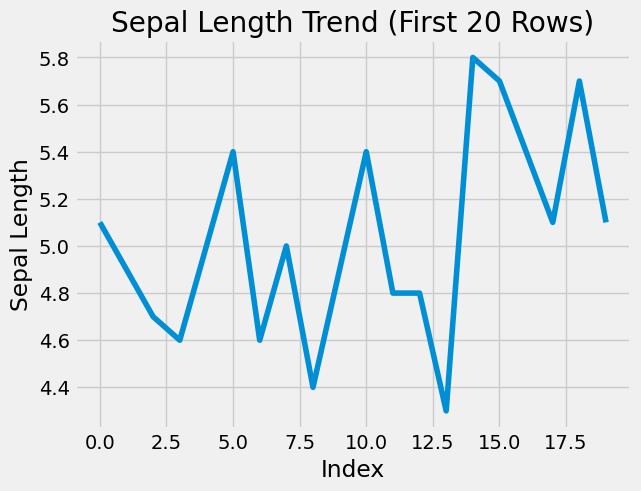

In [ ]:
# Plot a line graph of sepal_length for first 20 rows.

plt.plot(df['sepal_length'][:20])
plt.title("Sepal Length Trend (First 20 Rows)")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

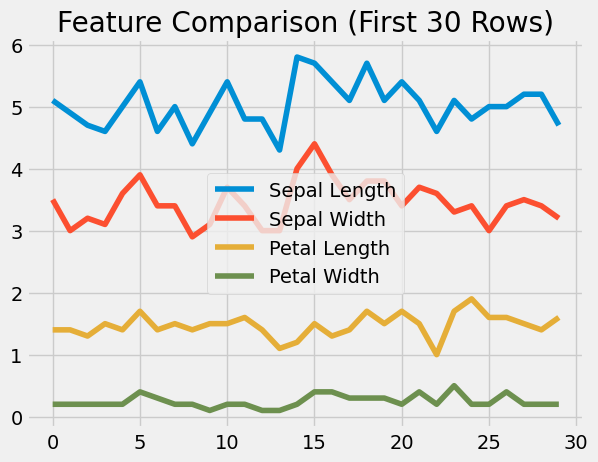

In [ ]:
# Compare all 4 features in one line chart (first 30 rows).

plt.plot(df['sepal_length'][:30], label='Sepal Length')
plt.plot(df['sepal_width'][:30], label='Sepal Width')
plt.plot(df['petal_length'][:30], label='Petal Length')
plt.plot(df['petal_width'][:30], label='Petal Width')

plt.legend()
plt.title("Feature Comparison (First 30 Rows)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import numpy as np

y_pred_labels = np.argmax(model.predict(X_test), axis=1) # Convert multi-output predictions to class labels
y_test_labels = np.argmax(y_test, axis=1) # Convert one-hot encoded y_test to class labels

print(f"Accuracy: {accuracy_score(y_test_labels,y_pred_labels)}")
print(f"Precision (weighted): {precision_score(y_test_labels,y_pred_labels,average='weighted')}")
print(f"Recall (weighted): {recall_score(y_test_labels,y_pred_labels,average='weighted')}")
print(f"F1 Score (weighted): {f1_score(y_test_labels,y_pred_labels,average='weighted')}")

Accuracy: 0.9333333333333333
Precision (weighted): 0.9333333333333333
Recall (weighted): 0.9333333333333333
F1 Score (weighted): 0.9333333333333333


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred_proba = dt_model.predict(X_test)
dt_pred_labels = np.argmax(dt_pred_proba, axis=1)

# 2. Random forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train,y_train)
rf_pred_proba = rf_model.predict(X_test)
rf_pred_labels = np.argmax(rf_pred_proba, axis=1)

# Convert y_test to labels for comparison
y_test_labels = np.argmax(y_test, axis=1)

# 3. Compare Accuracies
dt_accuracy = accuracy_score(y_test_labels, dt_pred_labels)
rf_accuracy = accuracy_score(y_test_labels, rf_pred_labels)

print(f"Decision Tree Accuracy: {dt_accuracy}")
print(f"Random Forest Accuracy: {rf_accuracy}")

Decision Tree Accuracy: 0.9333333333333333
Random Forest Accuracy: 0.9333333333333333
